In [1]:
import os
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np

from pertpy.tools import Milo


/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_age_cd8= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_cd8

AnnData object with n_obs × n_vars = 248612 × 2889
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collect

In [4]:
adata_age_cd8.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      57390
4–6      60061
7–10     38486
11–14    68909
15–18    23766
Name: count, dtype: int64

In [5]:
adata_age_cd8.obs['cell_type'].unique()
adata_age_cd8.obs['cell_type'].value_counts()

cell_type
Naive/Central memory CD8 T cell      164455
CD8+ gdT cell                         21412
GZMK+ CD8 T cell                      14741
CD8 Temra                             13162
TOX+ CD8 T cell                       10777
CD27+ CCR7+ suppressed CD8 T cell     10741
CD27- CCR7- suppressed CD8 T cell      9596
CD27+ CCR7- suppressed CD8 T cell      2749
Suppressed CD8 T cell                   693
Inhibitory KIR+ CD8 T cell              220
CD8 TEM                                  46
GZMK+ memory CD8 T cell                  13
Efector memory CD8 T cell                 7
Name: count, dtype: int64

In [6]:
adata_age_cd8.obs["pica_id"].unique()
adata_age_cd8.obs["pica_id"].value_counts()

pica_id
PICA0040    3791
PICA0141    3720
PICA0140    3310
PICA0173    3205
PICA0039    3058
            ... 
PICA0010     563
PICA0005     480
PICA0003     438
PICA0004     391
PICA0002     391
Name: count, Length: 128, dtype: int64

In [7]:
adata_age_cd8.obs["Age_group"] = pd.Categorical(
        adata_age_cd8.obs["Age_group"],
        categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
        ordered=True,
    )

In [8]:
adata_age_cd8.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      57390
4–6      60061
7–10     38486
11–14    68909
15–18    23766
Name: count, dtype: int64

In [9]:
adata_age_cd8.obs["Child_sex"] = adata_age_cd8.obs["Child's sex"].astype("category")

In [10]:
adata_age_cd8.obs[["Child's sex", "Child_sex"]].head()
adata_age_cd8.obs["Child_sex"].value_counts()

Child_sex
Male      140104
Female    108508
Name: count, dtype: int64

In [11]:
adata_age_cd8.obs["Child_sex"].astype(str).value_counts(dropna=False)
sorted(adata_age_cd8.obs["Child_sex"].astype(str).unique())

['Female', 'Male']

In [12]:
sc.pp.neighbors(
    adata_age_cd8,
    use_rep="X_scVI",
    n_neighbors=30,
    key_added="scvi_neighbors"
)

In [13]:

milo = pt.tl.Milo() # initialise

# Build neighbourhood graph
milo.make_nhoods(
    adata_age_cd8,
    neighbors_key="scvi_neighbors",
    prop=0.1,
    copy=False
)

In [14]:
mdata = milo.count_nhoods(adata_age_cd8, sample_col="pica_id") 

In [15]:
for col in ["Age_group", "Child_sex"]:
    if col not in mdata["milo"].obs.columns and col in adata_age_cd8.obs.columns:
        # donor-level covariates: take the first value per donor (should be constant per donor)
        mdata["milo"].obs[col] = (
            adata_age_cd8.obs[[col, "pica_id"]]
            .drop_duplicates("pica_id")
            .set_index("pica_id")
            .loc[mdata["milo"].obs_names, col]
            .values
        )

In [16]:
milo.build_nhood_graph(mdata)

In [17]:
mdata

MuData object with n_obs × n_vars = 248740 × 16644
  2 modalities
    rna:	248612 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Child_sex', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'scvi_neighbors', 'nhood_neighbors_key'
      obsm:	'X_pca', 'X_scVI', 'X_umap', 'nhoods'
      

In [26]:
mdata.write_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_nhood.h5mu")

### Male enrichment model (Female reference)

In [2]:
mdata_m=mu.read_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_nhood.h5mu")

In [28]:
mdata_m["milo"].obs["Child_sex"] = pd.Categorical(
    mdata_m["milo"].obs["Child_sex"],
    categories=["Female", "Male"],   # Female reference
    ordered=True
)

In [29]:
milo = pt.tl.Milo()
# differential abundance test
milo.da_nhoods(
    mdata_m,
    design="~ Age_group + Child_sex"
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 2.98 seconds.

Fitting MAP dispersions...
... done in 2.91 seconds.

Fitting dispersions...
... done in 3.32 seconds.

Fitting MAP dispersions...
... done in 3.05 seconds.

Fitting dispersions...
... done in 2.96 seconds.

Fitting MAP dispersions...
... done in 3.12 seconds.

Fitting dispersions...
... done in 2.61 seconds.

Fitting MAP dispersions...
... done in 3.10 seconds.

Fitting dispersions...
... done in 2.35 seconds.

Fitting MAP dispersions...
... done in 3.19 seconds.

Fitting dispersions...
... done in 1.95 seconds.

Fitting MAP dispersions...
... done in 3.26 seconds.

Fitting dispersions...
... done in 2.21 seconds.

Fitting MAP dispersions...
... done in 3.38 seconds.

Fitting dispersions.

Log2 fold change & Wald test p-value: Child_sex Male vs Female
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0        9.957607        1.070935  0.767424  1.395493  0.162867  0.302417
1       11.591407       -0.605287  0.873710 -0.692777  0.488449  0.586185
2        6.575055        1.614421  0.918616  1.757449  0.078841       NaN
3        1.179175        1.786223  1.197852  1.491189  0.135912       NaN
4        9.620381        2.060344  0.848303  2.428783  0.015150  0.116898
...           ...             ...       ...       ...       ...       ...
13750   51.172022        1.648265  1.500424  1.098532  0.271972  0.402834
13751   52.007965        1.183840  1.192547  0.992699  0.320857  0.443810
13752    7.970077        0.908758  0.995346  0.913007  0.361239  0.480711
13753    2.088476        1.485964  0.671621  2.212503  0.026932       NaN
13754  719.753910        1.969064  1.196691  1.645423  0.099883  0.233490

[13755 rows x 6 columns]


... done in 1.62 seconds.



In [30]:
mdata_m.write_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_M_DA.h5mu")

### Annotation

In [2]:
mdata_m=mu.read_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_M_DA.h5mu")

In [3]:
milo = pt.tl.Milo()
mdata_m

MuData object with n_obs × n_vars = 248740 × 16644
  2 modalities
    rna:	248612 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Child_sex', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'nhood_neighbors_key', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 'scvi_neighbors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_pca', 'X_scVI', 'X_umap', 'nhoods'
      

In [4]:
res = mdata_m["milo"].var

# How many significant neighbourhoods?
print("Sig nhoods (SpatialFDR<0.05):", (res["SpatialFDR"] < 0.05).sum())

# Quick logFC summary of significant nhoods
sig = res[res["SpatialFDR"] < 0.05]
print(sig["logFC"].describe())

# Direction check (depends on your reference)
print("logFC > 0:", (sig["logFC"] > 0).sum(), " | logFC < 0:", (sig["logFC"] < 0).sum())

Sig nhoods (SpatialFDR<0.05): 5
count    5.000000
mean     3.211865
std      0.433819
min      2.627171
25%      3.009980
50%      3.211229
75%      3.431811
max      3.779133
Name: logFC, dtype: float64
logFC > 0: 5  | logFC < 0: 0


In [5]:
da_male_enriched = mdata_m["milo"].var.copy()
da_male_enriched["enriched_group"] = "Male"
da_male_enriched["sex_reference"] = "Female"

In [6]:
M = mdata_m["rna"].obsm["nhoods"]          # cells x nhoods (sparse)
logFC = mdata_m["milo"].var["logFC"].to_numpy()
spFDR = mdata_m["milo"].var["SpatialFDR"].to_numpy()

In [7]:
# 1) per-cell average logFC over nhoods the cell belongs to
den = np.asarray(M.sum(axis=1)).ravel()
num = M @ logFC
cell_logFC = np.asarray(num).ravel()
cell_logFC = np.divide(cell_logFC, den, out=np.full_like(cell_logFC, np.nan, dtype=float), where=den>0)
mdata_m["rna"].obs["nhood_logFC"] = cell_logFC


In [8]:
# 2) per-cell min SpatialFDR over nhoods the cell belongs to (more conservative)
#    (efficient row-wise loop over sparse CSR indices)
M_csr = M.tocsr()
cell_min_spFDR = np.full(M_csr.shape[0], np.nan, dtype=float)
for i in range(M_csr.shape[0]):
    idx = M_csr.indices[M_csr.indptr[i]:M_csr.indptr[i+1]]
    if idx.size:
        cell_min_spFDR[i] = np.min(spFDR[idx])
mdata_m["rna"].obs["nhood_SpatialFDR"] = cell_min_spFDR

In [9]:
male_cell_cols = [c for c in mdata_m["rna"].obs.columns if c.startswith("nhood_")]
for c in male_cell_cols:
    mdata_m["rna"].obs[f"male_{c}"] = mdata_m["rna"].obs[c].values

cell_male_enriched = mdata_m["rna"].obs[[f"male_{c}" for c in male_cell_cols]].copy()

print("Male-enriched nhoods (SpatialFDR<0.05):", (da_male_enriched["SpatialFDR"] < 0.05).sum())


Male-enriched nhoods (SpatialFDR<0.05): 5


In [10]:
mdata_m.uns["milo_DA_ChildSex_male_enriched"] = da_male_enriched
mdata_m.uns["milo_cells_ChildSex_male_enriched"] = cell_male_enriched
mdata_m

MuData object with n_obs × n_vars = 248740 × 16644
  2 modalities
    rna:	248612 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Child_sex', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'nhood_logFC', 'nhood_SpatialFDR', 'male_nhood_ixs_random', 'male_nhood_ixs_refined', 'male_nhood_kth_distance', 'male_nhood_logFC', 'male_nhood_SpatialFDR'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'nhood_neighbors_key', 'pca', 'pica_b

In [11]:
mdata_m["milo"].obs.shape

(128, 3)

In [12]:
mdata_m.write_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_M_annot_DA.h5ad")

In [13]:
da_male_enriched.to_csv("/scratch/user/s4575250/BIOX7018_thesis/data/figures/PICA_Batch001-Batch007/03_milo/cd8_milo_DA_ChildSex_male_enriched.csv")
cell_male_enriched.to_csv("/scratch/user/s4575250/BIOX7018_thesis/data/figures/PICA_Batch001-Batch007/03_milo/cd8_milo_cells_ChildSex_male_enriched.csv")

In [15]:
mdata_m=mu.read_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_M_annot_DA.h5ad")

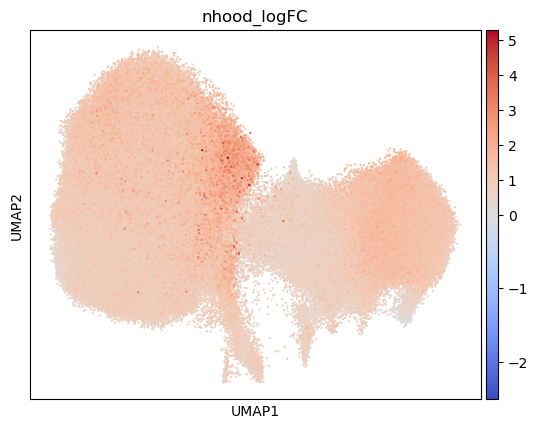

In [16]:
# continuous logFC
sc.pl.umap(
    mdata_m["rna"],
    color="nhood_logFC",
    cmap="coolwarm",
    vcenter=0,
    size=10
)

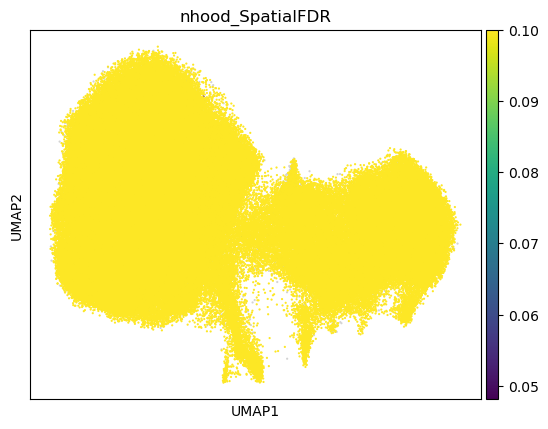

In [17]:
# significant neighbourhoods only
sc.pl.umap(
    mdata_m["rna"],
    color="nhood_SpatialFDR",
    vmax=0.1,
    size=10
)

In [18]:
if "design_matrix" in mdata_m["milo"].uns:
    print("Male design_matrix columns:", list(mdata_m["milo"].uns["design_matrix"].columns))
    display(mdata_m["milo"].uns["design_matrix"].head())


In [19]:
if "cell_type" in mdata_m["rna"].obs.columns:
    mdata_m["rna"].obs.groupby("cell_type")["male_nhood_logFC"].mean().sort_values()

/scratch/temp/18809934/ipykernel_3614353/421390495.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mdata_m["rna"].obs.groupby("cell_type")["male_nhood_logFC"].mean().sort_values()


In [20]:
obs = mdata_m["rna"].obs

obs["sex_enrichment"] = "not_significant"

sig = obs["male_nhood_SpatialFDR"] < 0.1

obs.loc[sig & (obs["male_nhood_logFC"] > 0), "sex_enrichment"] = "male_enriched"
obs.loc[sig & (obs["male_nhood_logFC"] < 0), "sex_enrichment"] = "female_enriched"


In [21]:
pd.crosstab(
    mdata_m["rna"].obs["cell_type"],
    mdata_m["rna"].obs["sex_enrichment"],
    normalize="index"
)

sex_enrichment,male_enriched,not_significant
cell_type,,
CD8 TEM,0.000000,1.000000
CD8 Temra,0.000000,1.000000
CD8+ gdT cell,0.000047,0.999953
CD27+ CCR7+ suppressed CD8 T cell,0.000838,0.999162
CD27+ CCR7- suppressed CD8 T cell,0.000000,1.000000
CD27- CCR7- suppressed CD8 T cell,0.000000,1.000000
Efector memory CD8 T cell,0.000000,1.000000
GZMK+ CD8 T cell,0.001221,0.998779
GZMK+ memory CD8 T cell,0.000000,1.000000


Text(0, 0.5, '-log10(SpatialFDR)')

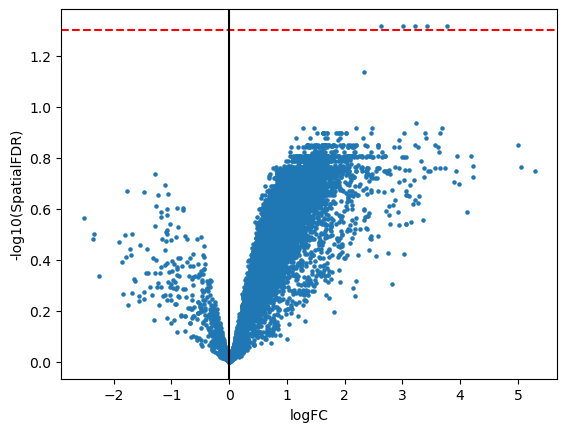

In [22]:
import matplotlib.pyplot as plt

df = mdata_m["milo"].var
plt.scatter(df["logFC"], -np.log10(df["SpatialFDR"]), s=5)
plt.axhline(-np.log10(0.05), color="red", ls="--")
plt.axvline(0, color="black")
plt.xlabel("logFC")
plt.ylabel("-log10(SpatialFDR)")

### Female enriched model (Male reference)

In [9]:
mdata_f=mu.read_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_nhood.h5mu")

In [35]:
mdata_f["milo"].obs["Child_sex"] = pd.Categorical(
    mdata_f["milo"].obs["Child_sex"],
    categories=["Male", "Female"],   # Male reference
    ordered=True)

In [36]:
milo = pt.tl.Milo()
# differential abundance test
milo.da_nhoods(
    mdata_f,
    design="~ Age_group + Child_sex"
)

Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(


Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.93 seconds.

Fitting MAP dispersions...
... done in 2.99 seconds.

Fitting dispersions...
... done in 2.93 seconds.

Fitting MAP dispersions...
... done in 3.10 seconds.

Fitting dispersions...
... done in 3.28 seconds.

Fitting MAP dispersions...
... done in 3.03 seconds.

Fitting dispersions...
... done in 2.54 seconds.

Fitting MAP dispersions...
... done in 3.06 seconds.

Fitting dispersions...
... done in 1.98 seconds.

Fitting MAP dispersions...
... done in 3.22 seconds.

Fitting dispersions...
... done in 2.22 seconds.

Fitting MAP dispersions...
... done in 3.34 seconds.

Fitting dispersions...
... done in 2.16 seconds.

Fitting MAP dispersions...
... done in 3.36 seconds.

Fitting dispersions...
... done in 2.57 seconds.

Fitting MAP dispersions...
... done in 3.27 seconds.

Fitting dispersions...
... done in 3.34 seconds.

Fitting MAP dispersions...
... done in 3.22 seconds.

Fitting dispersions...
... done in 3.34 seconds.

Fitting MAP di

Log2 fold change & Wald test p-value: Child_sex Male vs Female
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0        9.957607        1.070935  0.767424  1.395493  0.162867  0.302417
1       11.591407       -0.605287  0.873710 -0.692777  0.488449  0.586185
2        6.575055        1.614421  0.918616  1.757449  0.078841       NaN
3        1.179175        1.786223  1.197852  1.491189  0.135912       NaN
4        9.620381        2.060344  0.848303  2.428783  0.015150  0.116898
...           ...             ...       ...       ...       ...       ...
13750   51.172022        1.648265  1.500424  1.098532  0.271972  0.402834
13751   52.007965        1.183840  1.192547  0.992699  0.320857  0.443810
13752    7.970077        0.908758  0.995346  0.913007  0.361239  0.480711
13753    2.088476        1.485964  0.671621  2.212503  0.026932       NaN
13754  719.753910        1.969064  1.196691  1.645423  0.099883  0.233490

[13755 rows x 6 columns]


... done in 1.61 seconds.



In [37]:
mdata_f.write_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_F_DA.h5mu")

### Annotation

In [14]:
mdata_f=mu.read_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_F_DA.h5mu")

In [15]:
milo = pt.tl.Milo()
mdata_f

MuData object with n_obs × n_vars = 248740 × 16644
  2 modalities
    rna:	248612 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Child_sex', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'nhood_neighbors_key', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 'scvi_neighbors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_pca', 'X_scVI', 'X_umap', 'nhoods'
      

In [16]:
res = mdata_f["milo"].var

# How many significant neighbourhoods?
print("Sig nhoods (SpatialFDR<0.05):", (res["SpatialFDR"] < 0.05).sum())

# Quick logFC summary of significant nhoods
sig = res[res["SpatialFDR"] < 0.05]
print(sig["logFC"].describe())

# Direction check (depends on your reference)
print("logFC > 0:", (sig["logFC"] > 0).sum(), " | logFC < 0:", (sig["logFC"] < 0).sum())

Sig nhoods (SpatialFDR<0.05): 5
count    5.000000
mean     3.211865
std      0.433819
min      2.627171
25%      3.009980
50%      3.211229
75%      3.431811
max      3.779133
Name: logFC, dtype: float64
logFC > 0: 5  | logFC < 0: 0


In [17]:
da_female_enriched = mdata_f["milo"].var.copy()
da_female_enriched["enriched_group"] = "Female"
da_female_enriched["sex_reference"] = "Male"

In [18]:
F = mdata_f["rna"].obsm["nhoods"]          # cells x nhoods (sparse)
logFC = mdata_f["milo"].var["logFC"].to_numpy()
spFDR = mdata_f["milo"].var["SpatialFDR"].to_numpy()

In [19]:
# 1) per-cell average logFC over nhoods the cell belongs to
den = np.asarray(F.sum(axis=1)).ravel()
num = F @ logFC
cell_logFC = np.asarray(num).ravel()
cell_logFC = np.divide(cell_logFC, den, out=np.full_like(cell_logFC, np.nan, dtype=float), where=den>0)
mdata_f["rna"].obs["nhood_logFC"] = cell_logFC


In [20]:
# 2) per-cell min SpatialFDR over nhoods the cell belongs to (more conservative)
#    (efficient row-wise loop over sparse CSR indices)
F_csr = F.tocsr()
cell_min_spFDR = np.full(F_csr.shape[0], np.nan, dtype=float)
for i in range(F_csr.shape[0]):
    idx = F_csr.indices[F_csr.indptr[i]:F_csr.indptr[i+1]]
    if idx.size:
        cell_min_spFDR[i] = np.min(spFDR[idx])
mdata_f["rna"].obs["nhood_SpatialFDR"] = cell_min_spFDR

In [21]:
female_cell_cols = [c for c in mdata_f["rna"].obs.columns if c.startswith("nhood_")]
for c in female_cell_cols:
    mdata_f["rna"].obs[f"female_{c}"] = mdata_f["rna"].obs[c].values

cell_female_enriched = mdata_f["rna"].obs[[f"female_{c}" for c in female_cell_cols]].copy()

print("Feale-enriched nhoods (SpatialFDR<0.05):", (da_female_enriched["SpatialFDR"] < 0.05).sum())


Feale-enriched nhoods (SpatialFDR<0.05): 5


In [22]:
mdata_f.uns["milo_DA_ChildSex_female_enriched"] = da_female_enriched
mdata_f.uns["milo_cells_ChildSex_female_enriched"] = cell_female_enriched
mdata_f

MuData object with n_obs × n_vars = 248740 × 16644
  2 modalities
    rna:	248612 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Child_sex', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'nhood_logFC', 'nhood_SpatialFDR', 'female_nhood_ixs_random', 'female_nhood_ixs_refined', 'female_nhood_kth_distance', 'female_nhood_logFC', 'female_nhood_SpatialFDR'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'nhood_neighbors_key', 'pca

In [23]:
mdata_f["milo"].obs.shape

(128, 3)

In [24]:
mdata_f.write_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_F_annot_DA.h5ad")

In [25]:
da_female_enriched.to_csv("/scratch/user/s4575250/BIOX7018_thesis/data/figures/PICA_Batch001-Batch007/03_milo/cd8_milo_DA_ChildSex_female_enriched.csv")
cell_female_enriched.to_csv("/scratch/user/s4575250/BIOX7018_thesis/data/figures/PICA_Batch001-Batch007/03_milo/cd8_milo_cells_ChildSex_female_enriched.csv")

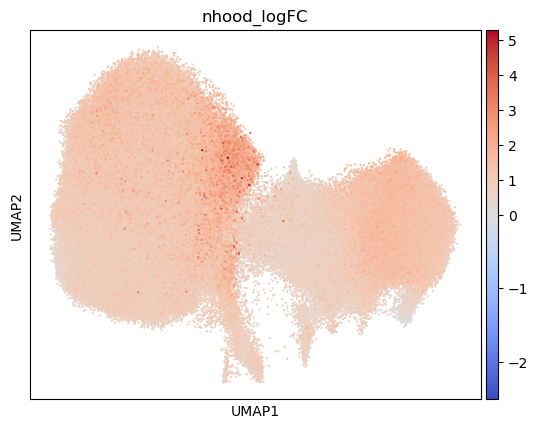

In [35]:
# continuous logFC
sc.pl.umap(
    mdata_f["rna"],
    color="nhood_logFC",
    cmap="coolwarm",
    vcenter=0,
    size=10
)

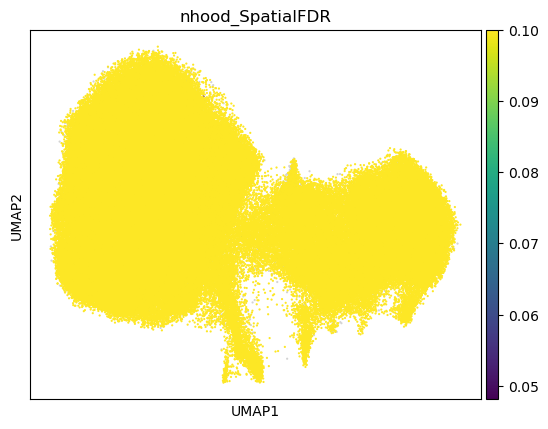

In [36]:
# significant neighbourhoods only
sc.pl.umap(
    mdata_f["rna"],
    color="nhood_SpatialFDR",
    vmax=0.1,
    size=10
)

In [37]:
if "design_matrix" in mdata_f["milo"].uns:
    print("Female design_matrix columns:", list(mdata_f["milo"].uns["design_matrix"].columns))
    display(mdata_f["milo"].uns["design_matrix"].head())


In [38]:
if "cell_type" in mdata_f["rna"].obs.columns:
    mdata_f["rna"].obs.groupby("cell_type")["female_nhood_logFC"].mean().sort_values()

/scratch/temp/18809934/ipykernel_3614353/2296256978.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mdata_f["rna"].obs.groupby("cell_type")["female_nhood_logFC"].mean().sort_values()


In [40]:
obs = mdata_f["rna"].obs

obs["sex_enrichment"] = "not_significant"

sig = obs["female_nhood_SpatialFDR"] < 0.1

obs.loc[sig & (obs["female_nhood_logFC"] > 0), "sex_enrichment"] = "male_enriched"
obs.loc[sig & (obs["female_nhood_logFC"] < 0), "sex_enrichment"] = "female_enriched"


In [41]:
pd.crosstab(
    mdata_f["rna"].obs["cell_type"],
    mdata_f["rna"].obs["sex_enrichment"],
    normalize="index"
)

sex_enrichment,male_enriched,not_significant
cell_type,,
CD8 TEM,0.000000,1.000000
CD8 Temra,0.000000,1.000000
CD8+ gdT cell,0.000047,0.999953
CD27+ CCR7+ suppressed CD8 T cell,0.000838,0.999162
CD27+ CCR7- suppressed CD8 T cell,0.000000,1.000000
CD27- CCR7- suppressed CD8 T cell,0.000000,1.000000
Efector memory CD8 T cell,0.000000,1.000000
GZMK+ CD8 T cell,0.001221,0.998779
GZMK+ memory CD8 T cell,0.000000,1.000000


Text(0, 0.5, '-log10(SpatialFDR)')

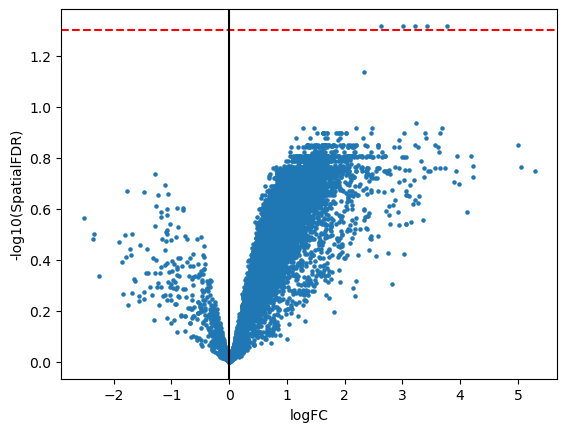

In [42]:
import matplotlib.pyplot as plt

df = mdata_f["milo"].var
plt.scatter(df["logFC"], -np.log10(df["SpatialFDR"]), s=5)
plt.axhline(-np.log10(0.05), color="red", ls="--")
plt.axvline(0, color="black")
plt.xlabel("logFC")
plt.ylabel("-log10(SpatialFDR)")

### merge male and female

In [ ]:
mdata_f= mu.read_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_F_annot_DA.h5ad")
mdata_m= mu.read_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_M_annot_DA.h5ad")

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_F_annot_DA.h5ad'

: 

In [ ]:
# align female object to male cell order
m_fem_rna_aligned = mdata_f["rna"][mdata_m["rna"].obs_names].copy()

In [ ]:
female_cols = [c for c in m_fem_rna_aligned.obs.columns if c.startswith("female_nhood_")]
print("Female columns to copy:", len(female_cols))

for c in female_cols:
    mdata_m["rna"].obs[c] = m_fem_rna_aligned.obs[c].values

In [ ]:
# Store DA tables into .uns for record
mdata_m.uns["milo_DA_ChildSex_male_enriched"] = mdata_m["milo"].var.copy()
mdata_m.uns["milo_DA_ChildSex_female_enriched"] = mdata_f["milo"].var.copy()

In [ ]:
mdata_m.write_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_CD8_milo_DA.h5mu")

### plots